# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import pandas as pd 
import numpy as np

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [4]:
from core.variables import * 
from core.estimators import *
from core.dgp import *
from core.experiments import *
from core.visualization import *

# Group Targeting

In [5]:
sample_size_df = pd.read_csv('results/sample_size_test.csv')
# get estimators 
estimators = [col[:-4] for col in sample_size_df.columns if '_est' in col]

# calculate winner's curse
for estimator in estimators:
    sample_size_df[f'{estimator}_wc'] = sample_size_df[f"{estimator}_est"] - sample_size_df['act_plugin_val']

# clean unnecessary columns
wc_columns = [f'{estimator}_wc' for estimator in estimators]
sample_size_df = sample_size_df[['sample_size'] + wc_columns + ['test_group_id', 'repeat_id']]

In [28]:
sample_size = 100
unit_basis = 0.1

test = sample_size_df[sample_size_df['sample_size'] == sample_size].drop(['sample_size', 'test_group_id', 'repeat_id'], axis=1) / unit_basis

print(test.mean())

print(test.std() / sample_size**0.5)

plugin_wc                  1.583215
error_correction_wc        0.504649
mnb_error_correction_wc    0.102932
nb_error_correction_wc     0.250239
value_correction_wc        0.498401
mnb_value_correction_wc    0.121258
nb_value_correction_wc     0.252120
dtype: float64
plugin_wc                  0.244359
error_correction_wc        0.272184
mnb_error_correction_wc    0.273097
nb_error_correction_wc     0.274040
value_correction_wc        0.272339
mnb_value_correction_wc    0.274379
nb_value_correction_wc     0.273996
dtype: float64


In [40]:
test = sample_size_df.drop(['test_group_id', 'repeat_id'], axis=1)
test.groupby('sample_size').mean() / unit_basis

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc,value_correction_wc,mnb_value_correction_wc,nb_value_correction_wc
sample_size,,,,,,,
100.0,1.583215,0.504649,0.102932,0.250239,0.498401,0.121258,0.252120
200.0,1.033095,0.247419,-0.018377,0.039924,0.247802,0.006370,0.040651
300.0,0.924691,0.318406,0.099577,0.134724,0.317030,0.105422,0.137320
400.0,0.664250,0.135087,-0.042175,-0.028435,0.139514,-0.051712,-0.026831
500.0,0.615935,0.154159,-0.009157,0.000731,0.155406,-0.001330,-0.000612
750.0,0.497755,0.140737,0.014092,0.005897,0.141509,0.013006,0.008781
1000.0,0.382457,0.086926,-0.017558,-0.033713,0.090793,-0.015792,-0.034158
1500.0,0.206931,-0.026382,-0.111985,-0.129343,-0.026084,-0.114144,-0.129797
2000.0,0.204165,0.012965,-0.059775,-0.079186,0.012915,-0.058836,-0.081235


Fixed Knobs:  sample_size: 100, num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

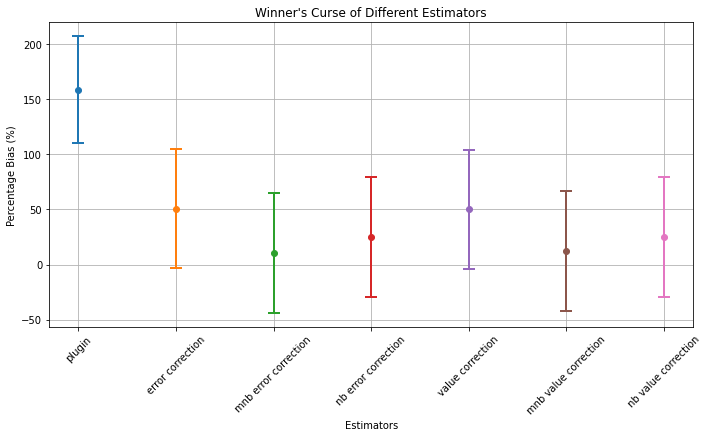

In [26]:
plot_winners_curse_errorbar('results/sample_size_test.csv', sample_size=100, unit_basis=0.1, confidence_level=0.95)

Fixed Knobs:  num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

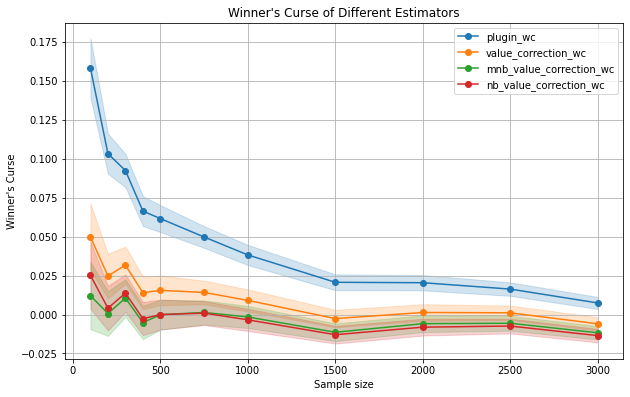

In [33]:
plot_winners_curse_2d(
    'results/sample_size_test.csv', 
    x='sample_size', confidence_level=0.95, estimators=['plugin', 'value_correction', 'mnb_value_correction', 'nb_value_correction']
)

In [49]:
def plot_winners_curse_2d(
    result_dir: str, x: str, confidence_level: float = 0.95, estimators: list = None, 
    basis_unit: float = 1, save_dir: str = None, **kwargs
):
    # read data
    result_df = pd.read_csv(result_dir)

    # get estimators 
    full_estimators = [col[:-4] for col in result_df.columns if '_est' in col]
    if estimators is None:
        estimators = full_estimators

    # check if x and y are columns in the dataframe
    assert x in result_df.columns, f'{x} is not a column in the dataframe'

    # fixed knobs keys 
    target_columns = [x] + [f'{estimator}_est' for estimator in full_estimators] + ['act_plugin_val', 'test_group_id', 'repeat_id']
    fixed_knob_keys = [col for col in result_df.columns if col not in target_columns]
    fixed_knob_vals = [result_df[key].iloc[0] if key not in kwargs.keys() else kwargs[key] for key in fixed_knob_keys]

    # print the fixed knobs
    print('Fixed Knobs: ', end=' ')
    for key, val in zip(fixed_knob_keys, fixed_knob_vals):
        print(f"{key}: {val},", end=' ')

    # extract the data for the fixed knobs
    fixed_knob_mask_list = np.array([
        (result_df[key] == val).values for key, val in zip(fixed_knob_keys, fixed_knob_vals)
    ])
    result_df = result_df[pd.Series(np.all(fixed_knob_mask_list, axis=0), index=result_df.index)]

    # calculate winner's curse
    for estimator in estimators:
        result_df[f'{estimator}_wc'] = result_df[f"{estimator}_est"] - result_df['act_plugin_val']

    # clean unnecessary columns
    wc_columns = [f'{estimator}_wc' for estimator in estimators]
    result_df = result_df[[x] + wc_columns + ['test_group_id', 'repeat_id']]

    result_df[wc_columns] = result_df[wc_columns] / basis_unit * 100

    # calcualte the average and standard deviation of the winner's curse across repeated trials
    mean_df = result_df.groupby([x])[wc_columns].mean().reset_index()
    se_df = result_df.groupby([x])[wc_columns].sem().reset_index()

    # calculate the confidence interval
    z = t.ppf(1 - (1 - confidence_level) / 2, result_df.groupby([x])[wc_columns].count().iloc[0, 0] - 1)

    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    for i, estimator_name in enumerate(wc_columns):
        ax.plot(mean_df[x], mean_df[estimator_name], 'o-', label=estimator_name, color=f'C{i}')
        ax.fill_between(
            mean_df[x], 
            mean_df[estimator_name] - z * se_df[estimator_name], 
            mean_df[estimator_name] + z * se_df[estimator_name], 
            alpha=0.2, color=f'C{i}'
        )

    ax.set_xlabel(x.replace('_', ' ').capitalize())
    ax.set_ylabel('Percentage Bias (%)')
    ax.set_title(f'Winner\'s Curse of Different Estimators')
    ax.grid()
    ax.legend()

    if save_dir is not None:
        plt.savefig(save_dir)

    plt.show()

Fixed Knobs:  num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

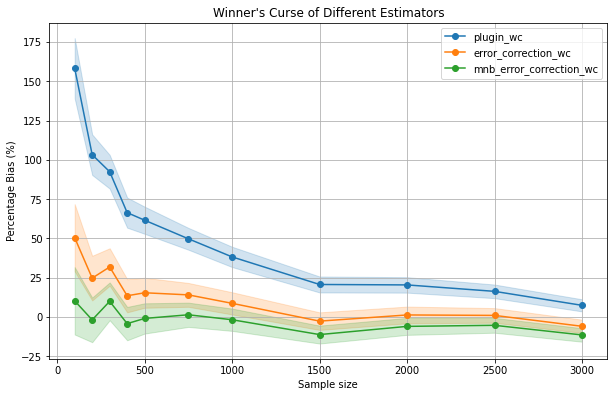

In [52]:
plot_winners_curse_2d(
    'results/sample_size_test.csv', basis_unit=0.1, 
    x='sample_size', confidence_level=0.95, estimators=['plugin', 'error_correction', 'mnb_error_correction'], 
    save_dir='figures/consumer_targeting_sample_size_test.png'
)

Fixed Knobs:  sample_size: 500.0, num_bootstrap: 200.0, noise_std: 1.0, 

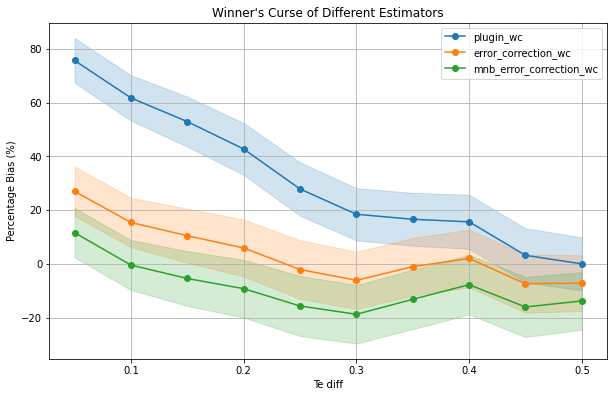

In [54]:
plot_winners_curse_2d(
    'results/te_diff_test.csv', basis_unit=0.1, 
    x='te_diff', confidence_level=0.95, estimators=['plugin', 'error_correction', 'mnb_error_correction'], 
    save_dir='figures/consumer_targeting_te_diff_test.png'
)

Fixed Knobs:  sample_size: 500.0, num_bootstrap: 200.0, te_diff: 0.1, 

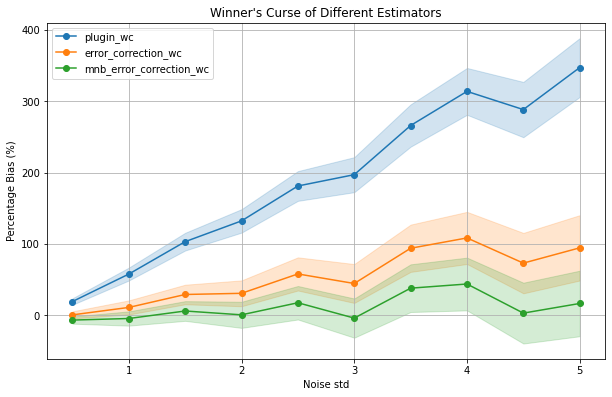

In [58]:
plot_winners_curse_2d(
    'results/noise_std_test.csv', basis_unit=0.1, 
    x='noise_std', confidence_level=0.95, estimators=['plugin', 'error_correction', 'mnb_error_correction'], 
    save_dir='figures/consumer_targeting_noise_std_test.png'
)

# Price Targeting